# Analyse results from Pypsa-Earth

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Own setting

In [1]:
import os
import sys
import yaml

PARENT = os.path.realpath("../../pypsa-earth") + "/"
config = yaml.safe_load(open(PARENT + "config-2030-NetZero-3TWh-Hydro.yaml"))

# Read config.yaml settings:
name = config["run"]["name"]
simpl = config["scenario"]["simpl"]
# clusters = "10"
clusters = config["scenario"]["clusters"]
ll = config["scenario"]["ll"]
opts = config["scenario"]["opts"]

# Ensure elements are strings and properly joined
simpl_str = "_".join(map(str, simpl))
clusters_str = "_".join(map(str, clusters))
#clusters_str = clusters
ll_str = "_".join(map(str, ll))
opts_str = "_".join(map(str, opts))
export = "1"
geothermal_potential = "3"

## Import packages

In [2]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

## Path settings

In [3]:
# nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}-{export}-{geothermal_potential}.nc"
nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}.nc"
scenario_name = name 
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
results_path = PARENT + f"results/{scenario_subpath}networks/{nc_file_name}"
network_path = PARENT + f"networks/{scenario_subpath}elec.nc"
# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [4]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

Country check

Text(0.5, 1.0, 'GH')

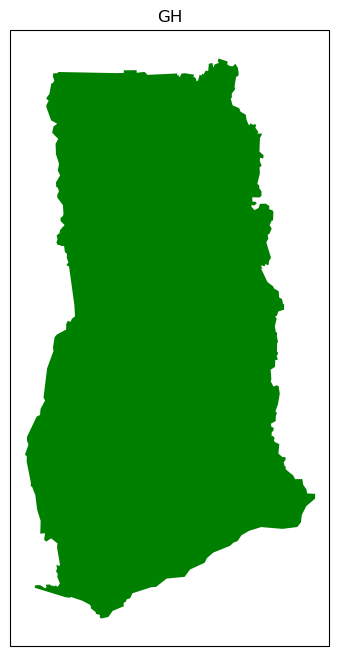

In [5]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [6]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 36 entries
Component 'Carrier' has 18 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 16 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 48 entries
Component 'Load' has 12 entries
Component 'Generator' has 66 entries
Component 'StorageUnit' has 2 entries
Component 'Store' has 24 entries


Snapshot check

In [7]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00',
               ...
               '2013-12-30 18:00:00', '2013-12-30 21:00:00',
               '2013-12-31 00:00:00', '2013-12-31 03:00:00',
               '2013-12-31 06:00:00', '2013-12-31 09:00:00',
               '2013-12-31 12:00:00', '2013-12-31 15:00:00',
               '2013-12-31 18:00:00', '2013-12-31 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=2920, freq=None)
Time steps: 2920


## Analyse energy system

Analyse the current capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


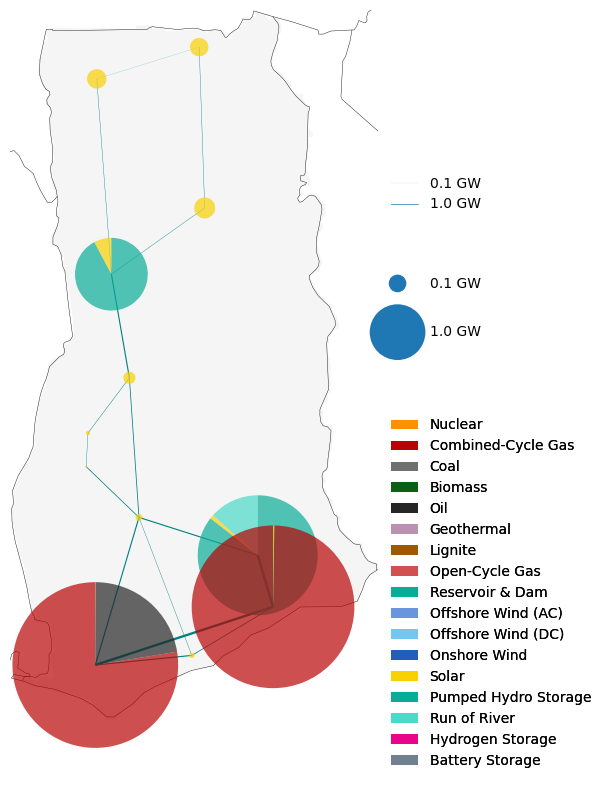

In [8]:
# Scale settings
bus_scale = 3e3 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

# n-noLoad = n.carriers.drop("Load", inplace=False)
n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.1,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 0.7e5, ylims[1])  # Extend the bottom by shifting downward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()
fig.savefig("brownfield_capacities_" + scenario_name + ".png", bbox_inches="tight", dpi=300)

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

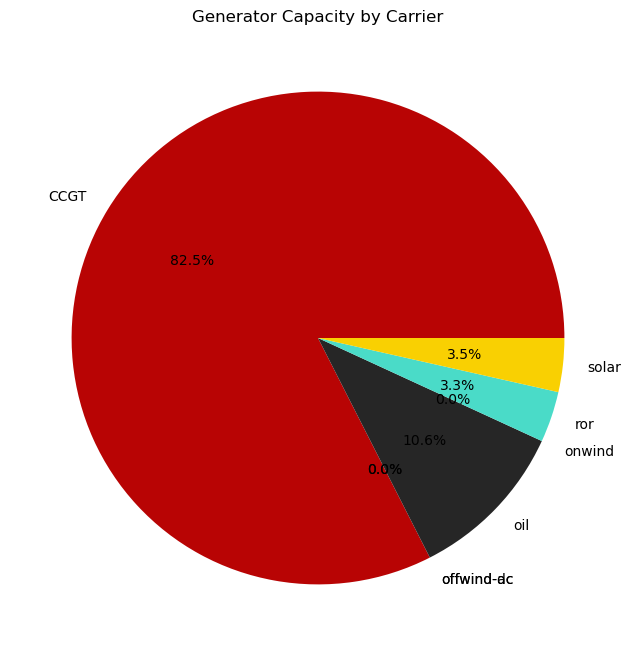

In [9]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
plt.pie(generator_capacity_by_carrier, labels=generator_capacity_by_carrier.index, autopct='%1.1f%%', colors=n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index))
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [10]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          3.952155
offwind-ac    0.000000
offwind-dc    0.000000
oil           0.509485
onwind        0.000000
ror           0.160000
solar         0.168954
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


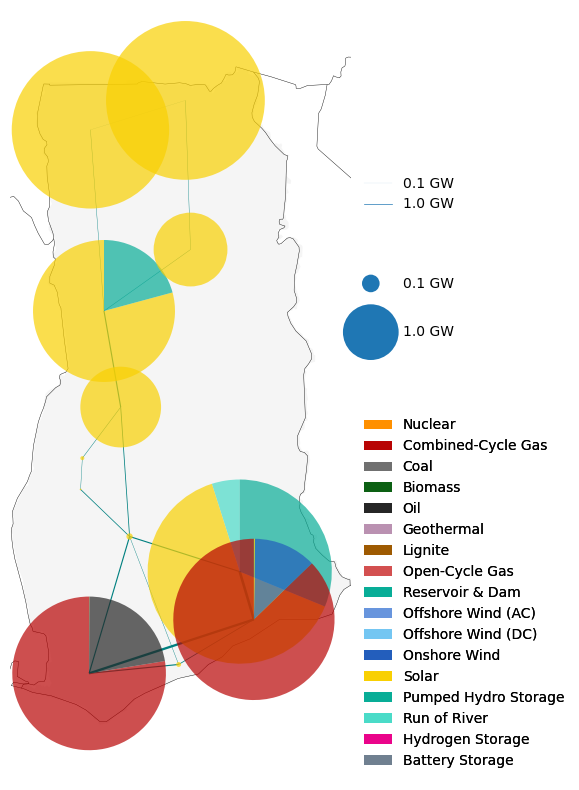

In [11]:
bus_scale = 3e3 
line_scale = 2e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 0.7e5, ylims[1] + 0.7e5)  # Extend the bottom by shifting downward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Calculate emissions of future energy system

In [12]:
#ToDo: Not fully correct - double check
co2_emissions = pd.DataFrame(data=n.carriers[["co2_emissions", "nice_name"]]).set_index("nice_name").squeeze().rename_axis("carrier")

energy_production = n.statistics.energy_balance().Generator.droplevel(1).drop(["load", "export"], errors="ignore")

co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]
co2_emissions_technology

/tmp/ipykernel_18353/272665663.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]


carrier
Offshore Wind (DC)    0.0
Onshore Wind          0.0
Run of River          0.0
Solar                 0.0
dtype: float64

In [13]:
co2_emissions_sum = co2_emissions_technology.sum()
co2_emissions_sum

0.0

In [14]:
n.global_constraints

,sense,mu,type,investment_period,carrier_attribute,constant
GlobalConstraint,,,,,,
CO2Limit,<=,-4682.625381,primary_energy,NaN,co2_emissions,0.0


In [15]:
# Step 1: Create the links_energy DataFrame with "carrier" and "bus0" columns
links_energy = n.links[["carrier", "bus0"]]

# Step 2: Filter only rows where "carrier" contains 'export'
links_energy = links_energy[links_energy["carrier"].str.contains("export", case=False, na=False)]

# Step 3: Calculate the energy sum for indices that contain 'export'
export_energy = n.links_t.p0.sum()
export_energy = export_energy[export_energy.index.str.contains("export", case=False, na=False)]

# Step 4: Map the energy sum to the correct rows in links_energy based on the index
links_energy["energy"] = links_energy.index.map(export_energy)

# Step 5: Group by "bus0" and "carrier" and sum the "energy" values
links_energy_grouped = links_energy.groupby(["bus0", "carrier"], as_index=False)["energy"].sum()

# Display the result
links_energy_grouped


,bus0,carrier,energy


Analys the future generation capacity expansion of the energy system - bar chart

In [16]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion

carrier
Combined-Cycle Gas    0.000000
Offshore Wind (DC)         NaN
Oil                   0.000000
Onshore Wind               NaN
Run of River          0.000000
Solar                 9.446116
load                  0.000000
dtype: float64

Plot the future generation capacity expansion of the energy system - tabular chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

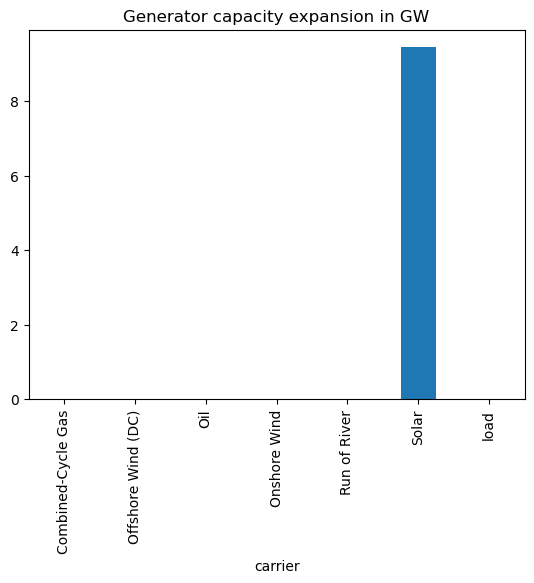

In [17]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Analyse the future energy generation of the energy system - bar chart view

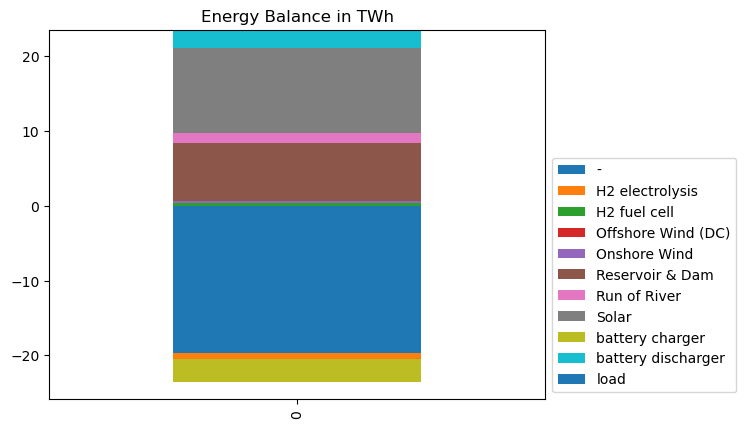

In [18]:
fig, ax = plt.subplots()
color_setting = n.carriers.set_index(n.carriers.nice_name)
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh")
n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index)

ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

Analyse the future energy generation of the energy system - tabular view

In [19]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier             bus_carrier
StorageUnit  Reservoir & Dam     AC             7.686043e+00
Link         H2 electrolysis     AC            -8.672736e-01
             H2 fuel cell        H2            -6.938188e-01
             battery charger     AC            -3.025354e+00
             battery discharger  battery       -2.722818e+00
             H2 electrolysis     H2             6.938188e-01
             H2 fuel cell        AC             4.024149e-01
             battery charger     battery        2.722818e+00
             battery discharger  AC             2.450536e+00
Store        Battery Storage     battery       -1.818350e-16
             Hydrogen Storage    H2            -1.624372e-16
Load         -                   AC            -1.965415e+01
Generator    Offshore Wind (DC)  AC             2.986375e-08
             Onshore Wind        AC             2.913540e-01
             Run of River        AC             1.401528e+00
             Solar               AC     

## Analyse pv and wind potential - map view

In [20]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    # br = gpd.read_file(f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br = gpd.read_file(PARENT + f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


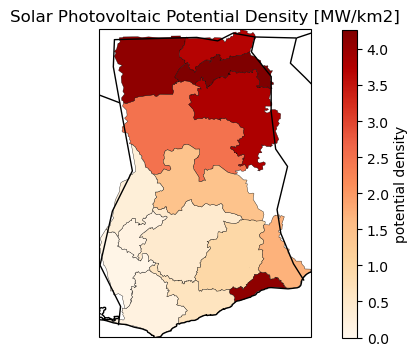

In [21]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


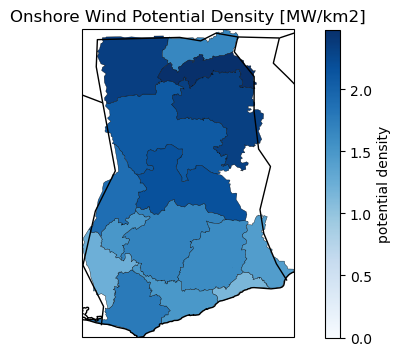

In [22]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Levelized cost of electricity

In [23]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity generation
# n.statistics.market_value() ?
lcoe = n.objective/n.statistics.energy_balance().Generator.sum()
lcoe 

58.71040635174107

In [24]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity demand
lcoe = n.objective/n.statistics.energy_balance().Load.sum()*(-1)
lcoe 

38.856539473314484

In [25]:
n.statistics.market_value()

component    carrier           
Generator    Offshore Wind (DC)    111.961227
             Onshore Wind          117.884533
             Run of River           84.262598
             Solar                  43.234009
             load                   74.608587
Line         AC                      0.776741
Link         H2 electrolysis        55.027049
             H2 fuel cell           28.319680
             battery charger        20.288506
             battery discharger      0.327974
Load         -                            NaN
StorageUnit  Reservoir & Dam       101.447695
Store        Battery Storage        50.179351
             Hydrogen Storage        8.640918
dtype: float64

Check storages

In [26]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
GH.11_2_AC hydro,hydro,GH.11_2_AC,404.0,2106.741573,0.0,0.9,0.0,True,,0.009920,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
GH.6_2_AC hydro,hydro,GH.6_2_AC,1020.0,2106.741573,0.0,0.9,0.0,True,,0.010793,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


## Additional input (Marco)

In [27]:
CCGT_col = [col for col in n.generators_t.p.columns if 'CCGT' in col]
n.generators_t.p[CCGT_col].sum()

Generator
GH.15_2_AC CCGT    0.0
GH.7_2_AC CCGT     0.0
dtype: float64

In [28]:
n.generators_t.p.columns

Index(['GH.11_2_AC H2 load', 'GH.11_2_AC battery load', 'GH.11_2_AC load',
       'GH.11_2_AC onwind', 'GH.11_2_AC solar', 'GH.12_2_AC H2 load',
       'GH.12_2_AC battery load', 'GH.12_2_AC load', 'GH.12_2_AC onwind',
       'GH.12_2_AC solar', 'GH.13_2_AC H2 load', 'GH.13_2_AC battery load',
       'GH.13_2_AC load', 'GH.13_2_AC onwind', 'GH.13_2_AC solar',
       'GH.15_2_AC CCGT', 'GH.15_2_AC H2 load', 'GH.15_2_AC battery load',
       'GH.15_2_AC load', 'GH.15_2_AC oil', 'GH.15_2_AC onwind',
       'GH.15_2_AC solar', 'GH.1_2_AC H2 load', 'GH.1_2_AC battery load',
       'GH.1_2_AC load', 'GH.1_2_AC onwind', 'GH.1_2_AC solar',
       'GH.2_2_AC H2 load', 'GH.2_2_AC battery load', 'GH.2_2_AC load',
       'GH.2_2_AC onwind', 'GH.2_2_AC solar', 'GH.3_2_AC H2 load',
       'GH.3_2_AC battery load', 'GH.3_2_AC load', 'GH.3_2_AC onwind',
       'GH.3_2_AC solar', 'GH.4_2_AC H2 load', 'GH.4_2_AC battery load',
       'GH.4_2_AC load', 'GH.4_2_AC onwind', 'GH.4_2_AC solar',
       'GH.5_

In [29]:
n.generators_t.p

Generator,GH.11_2_AC H2 load,GH.11_2_AC battery load,GH.11_2_AC load,GH.11_2_AC onwind,GH.11_2_AC solar,GH.12_2_AC H2 load,GH.12_2_AC battery load,GH.12_2_AC load,GH.12_2_AC onwind,GH.12_2_AC solar,...,GH.7_2_AC load,GH.7_2_AC offwind-ac,GH.7_2_AC offwind-dc,GH.7_2_AC onwind,GH.7_2_AC solar,GH.9_2_AC H2 load,GH.9_2_AC battery load,GH.9_2_AC load,GH.9_2_AC onwind,GH.9_2_AC solar
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.000004,0.000004,0.000004,3.061530e-05,0.000000,0.000004,0.000004,0.000004,0.000507,0.000000,...,0.000004,0.0,0.000000e+00,0.000000,0.000000,0.000004,0.000004,0.000004,0.000066,0.000000
2013-01-01 03:00:00,0.000004,0.000004,0.000004,2.666952e-05,0.000000,0.000004,0.000004,0.000004,0.000446,0.000000,...,0.000004,0.0,3.215259e-07,0.000000,0.000000,0.000004,0.000004,0.000004,0.000049,0.000000
2013-01-01 06:00:00,0.000004,0.000004,0.000004,1.947091e-05,72.299459,0.000004,0.000004,0.000004,0.000391,123.082621,...,0.000004,0.0,0.000000e+00,0.000000,0.316917,0.000004,0.000004,0.000004,0.000040,28.921343
2013-01-01 09:00:00,0.000004,0.000004,0.000004,1.234797e-05,663.350234,0.000004,0.000004,0.000004,0.000314,1066.045982,...,0.000004,0.0,0.000000e+00,19.419480,2.323200,0.000004,0.000004,0.000004,0.000032,230.418752
2013-01-01 12:00:00,0.000004,0.000004,0.000004,3.737911e-06,285.966344,0.000004,0.000004,0.000004,0.000074,1389.275490,...,0.000004,0.0,0.000000e+00,0.057812,2.337193,0.000004,0.000004,0.000004,0.000008,301.979832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31 09:00:00,0.000004,0.000004,0.000004,0.000000e+00,632.843914,0.000004,0.000004,0.000004,0.000041,1020.881888,...,0.000004,0.0,6.570589e-06,34.346645,1.911974,0.000004,0.000004,0.000004,0.000000,221.545072
2013-12-31 12:00:00,0.000004,0.000004,0.000004,0.000000e+00,375.968560,0.000004,0.000004,0.000004,0.000021,1344.505526,...,0.000004,0.0,2.343096e-06,0.060217,1.809829,0.000004,0.000004,0.000004,0.000000,285.993215
2013-12-31 15:00:00,0.000004,0.000004,0.000004,0.000000e+00,451.826275,0.000004,0.000004,0.000004,0.000000,787.211139,...,0.000004,0.0,3.593649e-06,70.211807,1.249771,0.000004,0.000004,0.000004,0.000000,161.111885


In [30]:
import re

df = n.generators_t.p

# Extract the category (everything after "GH0 <number> ")
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Create a mapping from the original column names to their categories
column_mapping = dict(zip(df.columns, categories))

# Group by category
grouped = {}
for col, category in column_mapping.items():
    grouped.setdefault(category, []).append(col)

# Print grouped columns
for category, cols in grouped.items():
    print(f"{category}: {cols}")

print(grouped)

GH.11_2_AC H2 load: ['GH.11_2_AC H2 load']
GH.11_2_AC battery load: ['GH.11_2_AC battery load']
GH.11_2_AC load: ['GH.11_2_AC load']
GH.11_2_AC onwind: ['GH.11_2_AC onwind']
GH.11_2_AC solar: ['GH.11_2_AC solar']
GH.12_2_AC H2 load: ['GH.12_2_AC H2 load']
GH.12_2_AC battery load: ['GH.12_2_AC battery load']
GH.12_2_AC load: ['GH.12_2_AC load']
GH.12_2_AC onwind: ['GH.12_2_AC onwind']
GH.12_2_AC solar: ['GH.12_2_AC solar']
GH.13_2_AC H2 load: ['GH.13_2_AC H2 load']
GH.13_2_AC battery load: ['GH.13_2_AC battery load']
GH.13_2_AC load: ['GH.13_2_AC load']
GH.13_2_AC onwind: ['GH.13_2_AC onwind']
GH.13_2_AC solar: ['GH.13_2_AC solar']
GH.15_2_AC CCGT: ['GH.15_2_AC CCGT']
GH.15_2_AC H2 load: ['GH.15_2_AC H2 load']
GH.15_2_AC battery load: ['GH.15_2_AC battery load']
GH.15_2_AC load: ['GH.15_2_AC load']
GH.15_2_AC oil: ['GH.15_2_AC oil']
GH.15_2_AC onwind: ['GH.15_2_AC onwind']
GH.15_2_AC solar: ['GH.15_2_AC solar']
GH.1_2_AC H2 load: ['GH.1_2_AC H2 load']
GH.1_2_AC battery load: ['GH.1_2_AC

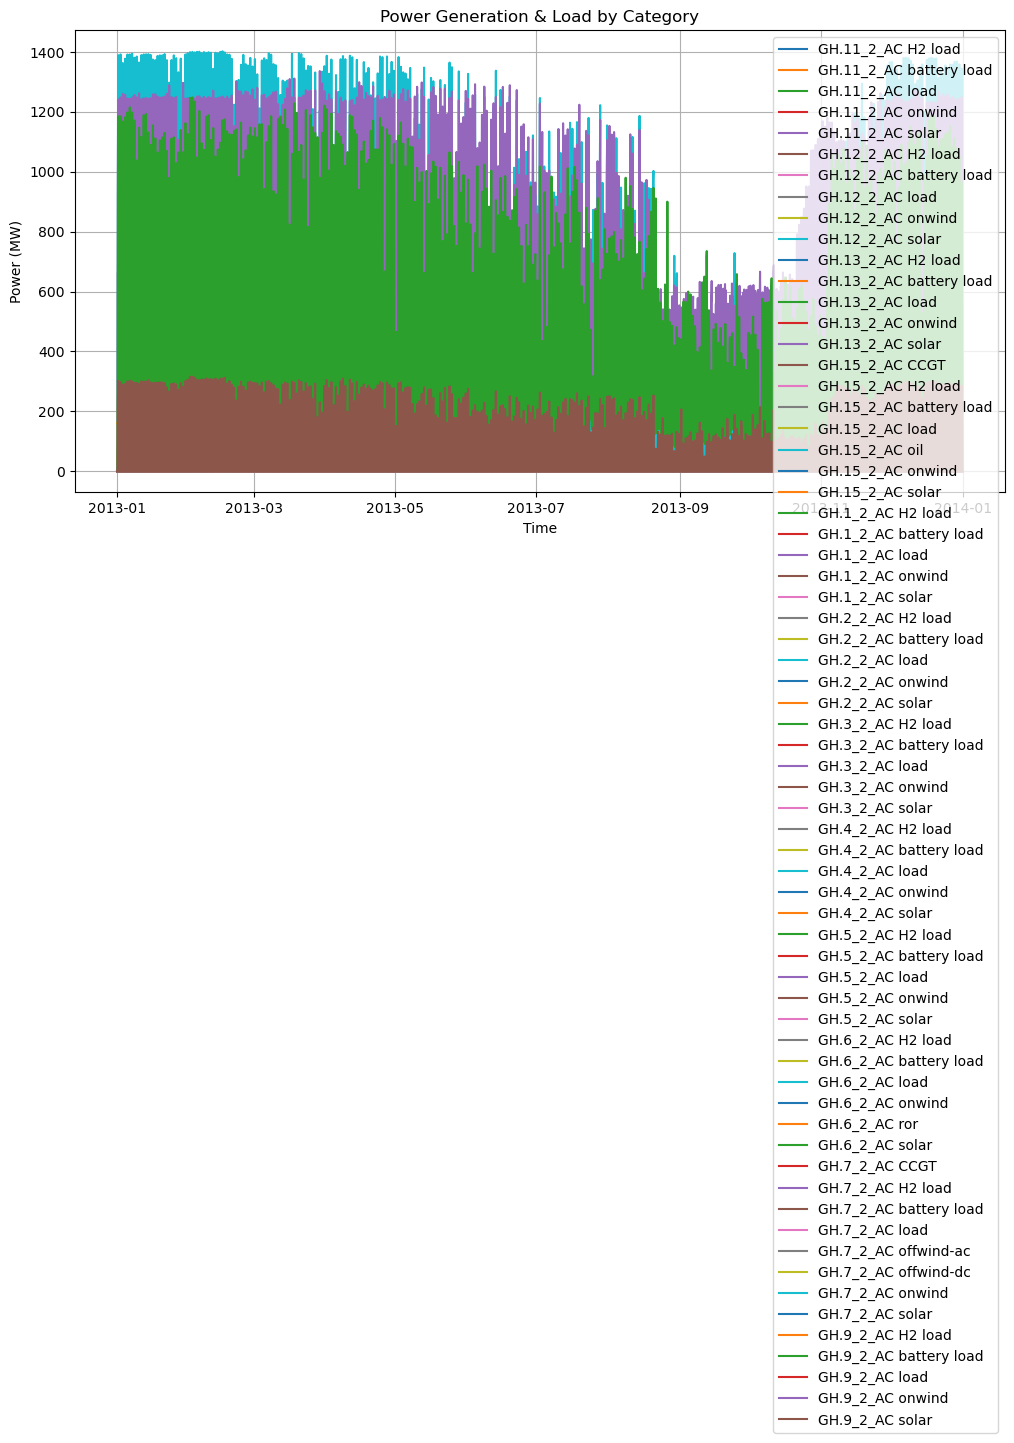

In [31]:
import pandas as pd
import re
import matplotlib.pyplot as plt


# Step 1: Extract category names
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Step 2: Create a mapping from category name to a list of columns
category_columns = {}
for col, category in zip(df.columns, categories):
    if category not in category_columns:
        category_columns[category] = []
    category_columns[category].append(col)

# Step 3: Sum data for each category and create a new DataFrame
grouped_data = pd.DataFrame({category: df[cols].sum(axis=1) for category, cols in category_columns.items()})

# Step 4: Plot the grouped time series
plt.figure(figsize=(12, 6))
for category in grouped_data.columns:
    plt.plot(grouped_data.index, grouped_data[category], label=category, linestyle="-")

# Formatting the plot
plt.xlabel("Time")
plt.ylabel("Power (MW)")  # Adjust based on your data units
plt.title("Power Generation & Load by Category")
plt.legend()
plt.grid(True)
plt.show()


Total load in 2013: 19.654152464746858 TWh


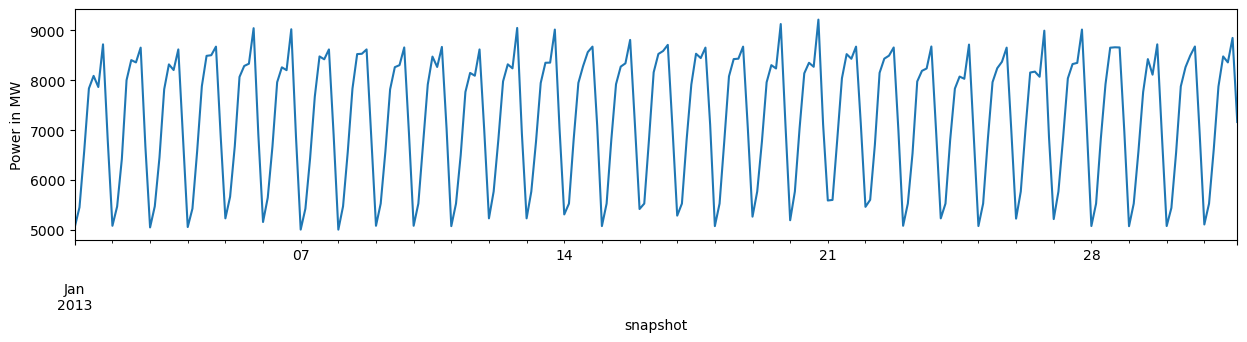

In [32]:
loads = n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0)
fig, ax = plt.subplots(figsize=(15, 3))
loads.sum(axis=1).loc['2013-01-01':'2013-01-31'].plot(ax=ax)
ax.set_ylabel('Power in MW')
print('Total load in 2013: {} TWh'.format(n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum(axis=1).sum() / 1000000))

In [33]:
n.objective / 1e9 # billion europs p.a.
print("The total system cost is {:.0f} million euros per year".format(n.objective / 1e6))

The total system cost is 764 million euros per year


## Line expansion

<AxesSubplot:xlabel='Line'>

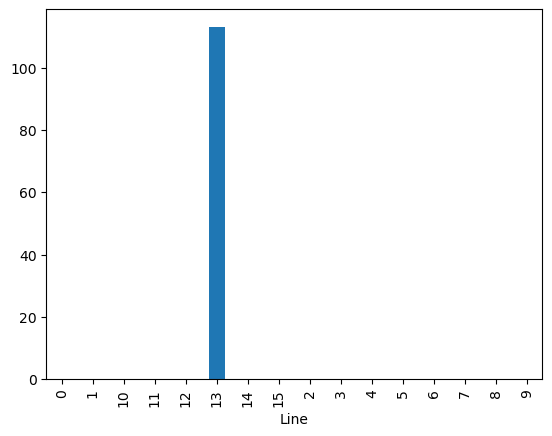

In [34]:
(n.lines.s_nom_opt - n.lines.s_nom).plot.bar()

Text(0, 0.5, 'Capacity in GW')

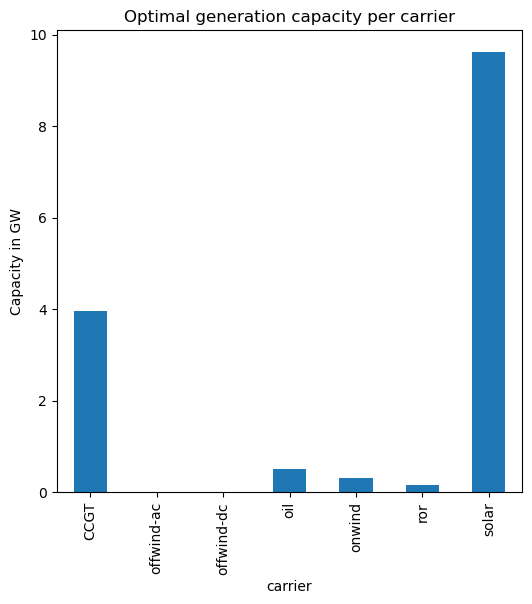

In [61]:
fig, ax = plt.subplots(figsize=(6,6))
n.generators.groupby('carrier').p_nom_opt.sum().multiply(1e-3).plot.bar(ax = ax)
ax.set_title('Optimal generation capacity per carrier')
ax.set_ylabel('Capacity in GW')

In [60]:
# n.generators.drop(n.generators[n.generators['carrier'] == 'load'], inplace=True)
n.generators = n.generators[n.generators['carrier'] != 'load']

In [37]:
n.storage_units.groupby('carrier').p_nom_opt.sum() / 1e3 # GW

carrier
hydro    1.424
Name: p_nom_opt, dtype: float64

<AxesSubplot:xlabel='snapshot'>

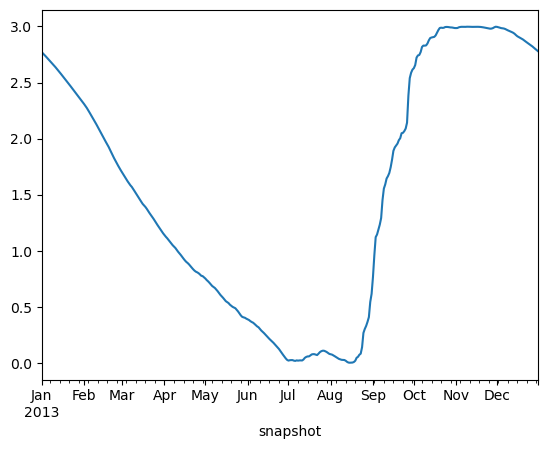

In [38]:
(n.storage_units_t.state_of_charge.sum(axis=1).resample('D').mean() / 1e6).plot()

In [39]:
n.storage_units_t.state_of_charge / 1e6

StorageUnit,GH.11_2_AC hydro,GH.6_2_AC hydro
snapshot,,
2013-01-01 00:00:00,0.778502,1.994722
2013-01-01 03:00:00,0.777982,1.992611
2013-01-01 06:00:00,0.777668,1.990535
2013-01-01 09:00:00,0.777794,1.991452
2013-01-01 12:00:00,0.777921,1.992368
...,...,...
2013-12-31 09:00:00,0.780488,1.999537
2013-12-31 12:00:00,0.780617,2.000457
2013-12-31 15:00:00,0.780745,2.001374


In [40]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
GH.11_2_AC hydro,hydro,GH.11_2_AC,404.0,2106.741573,0.0,0.9,0.0,True,,0.009920,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
GH.6_2_AC hydro,hydro,GH.6_2_AC,1020.0,2106.741573,0.0,0.9,0.0,True,,0.010793,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


In [41]:
n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()

bus         carrier   
GH.11_2_AC  onwind           0.000103
            solar         1538.889944
GH.12_2_AC  onwind           0.001137
            solar         2430.009299
GH.13_2_AC  onwind           0.000977
            solar         2388.330990
GH.15_2_AC  CCGT          1765.000000
            oil            509.484522
            onwind           0.000092
            solar            0.880162
GH.1_2_AC   onwind           0.000077
            solar            0.299700
GH.2_2_AC   onwind           0.000077
            solar            3.810608
GH.3_2_AC   onwind           0.000094
            solar            1.515781
GH.4_2_AC   onwind           0.000080
            solar          628.189113
GH.5_2_AC   onwind           0.000110
            solar            2.293681
GH.6_2_AC   onwind           0.000098
            ror            160.000000
            solar         2090.511562
GH.7_2_AC   CCGT          2187.154566
            offwind-ac       0.000000
            offwind-dc     

Text(0.5, 1.0, 'State of charge in TWh')

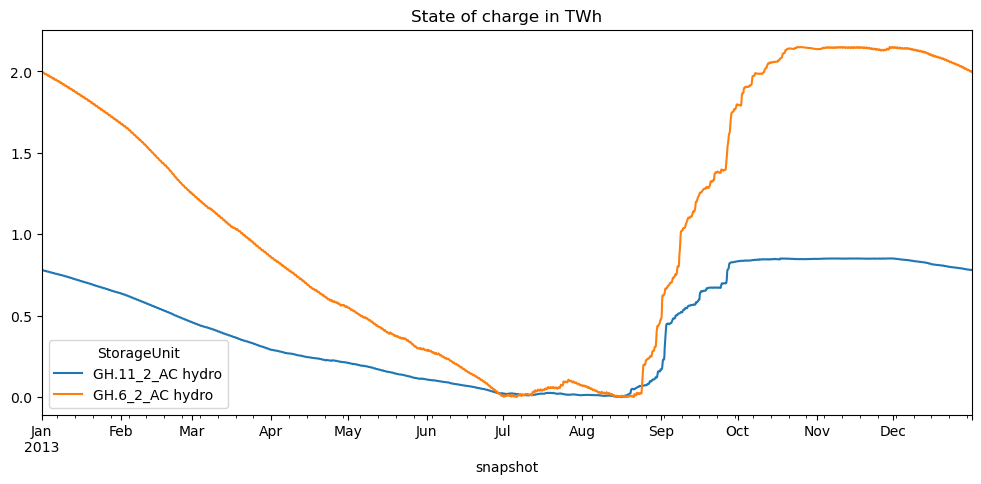

In [42]:
fig, ax = plt.subplots(figsize=(12,5))
(n.storage_units_t.state_of_charge / 1e6).plot(ax = ax)
ax.set_title('State of charge in TWh')

In [43]:
(n.storage_units_t.state_of_charge / 1e6)

StorageUnit,GH.11_2_AC hydro,GH.6_2_AC hydro
snapshot,,
2013-01-01 00:00:00,0.778502,1.994722
2013-01-01 03:00:00,0.777982,1.992611
2013-01-01 06:00:00,0.777668,1.990535
2013-01-01 09:00:00,0.777794,1.991452
2013-01-01 12:00:00,0.777921,1.992368
...,...,...
2013-12-31 09:00:00,0.780488,1.999537
2013-12-31 12:00:00,0.780617,2.000457
2013-12-31 15:00:00,0.780745,2.001374


<AxesSubplot:xlabel='snapshot'>

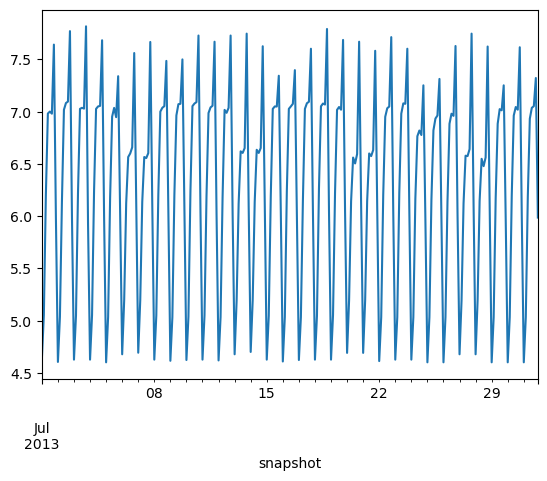

In [44]:
(n.loads_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

<AxesSubplot:xlabel='snapshot'>

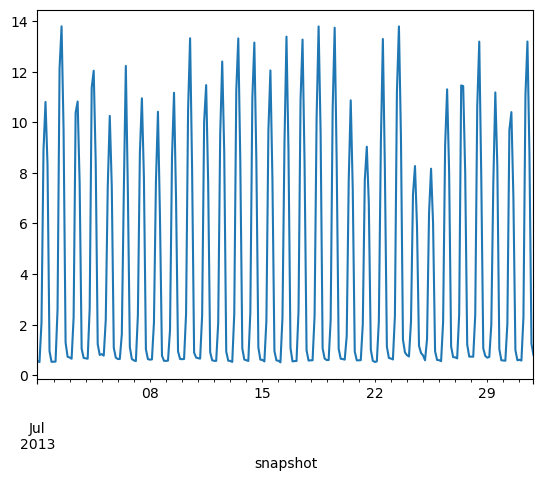

In [45]:
(n.generators_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

In [46]:
gen_snap = n.generators_t.p.loc['2013-01-01 18:00:00']
gen_snap

Generator
GH.11_2_AC H2 load         0.000004
GH.11_2_AC battery load    0.000004
GH.11_2_AC load            0.000004
GH.11_2_AC onwind          0.000006
GH.11_2_AC solar           0.000000
                             ...   
GH.9_2_AC H2 load          0.000004
GH.9_2_AC battery load     0.000004
GH.9_2_AC load             0.000004
GH.9_2_AC onwind           0.000021
GH.9_2_AC solar            0.000000
Name: 2013-01-01 18:00:00, Length: 66, dtype: float64

<AxesSubplot:xlabel='snapshot'>

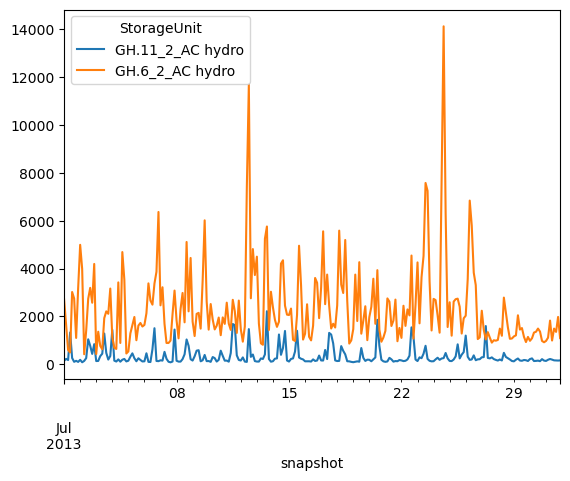

In [47]:
n.storage_units_t.inflow.multiply(n.snapshot_weightings.generators, axis=0).loc['2013-07'].plot()

In [48]:
n.statistics.capacity_factor(comps=["Generator", "StorageUnit"]).round(2)

component    carrier           
Generator    Offshore Wind (DC)    0.07
             Onshore Wind          0.11
             Run of River          1.00
             Solar                 0.13
StorageUnit  Reservoir & Dam       0.62
dtype: float64

In [49]:
n.statistics.supply().loc["StorageUnit"] / 1e6 # from MWh to TWh

carrier
Reservoir & Dam    7.686043
dtype: float64

In [50]:
n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6

/tmp/ipykernel_18353/2211605357.py:1: DeprecatedWarning: dispatch is deprecated as of 0.28 and will be removed in 0.29. Use 'energy_balance' instead.
  n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6


component    carrier           
Generator    Offshore Wind (DC)    3.000000e-08
             Onshore Wind          2.913540e-01
             Run of River          1.401528e+00
             Solar                 1.131490e+01
StorageUnit  Reservoir & Dam       7.686043e+00
dtype: float64

In [51]:
(n.storage_units_t.inflow.sum(axis=0) / 1e6 * 3).sum()# TWh

9.862710000000002

In [52]:
(n.storage_units_t.p.sum(axis=0) / 1e6 * 3).sum() # TWh

7.686043128490364

In [53]:
n.storage_units_t.spill.sum(axis=0) / 1e6

StorageUnit
GH.11_2_AC hydro    0.000021
GH.6_2_AC hydro     0.440866
dtype: float64

In [54]:
n.statistics.supply() / 1e6

component    carrier           
StorageUnit  Reservoir & Dam       7.686043e+00
Line         AC                    2.769693e+01
Link         H2 electrolysis       6.938188e-01
             H2 fuel cell          4.024149e-01
             battery charger       2.722818e+00
             battery discharger    2.450536e+00
Store        Battery Storage       2.722279e+00
             Hydrogen Storage      6.934614e-01
Generator    Offshore Wind (DC)    2.986375e-08
             Onshore Wind          2.913540e-01
             Run of River          1.401528e+00
             Solar                 1.131490e+01
dtype: float64

In [55]:
hydro_storage = n.storage_units["p_nom"] * n.storage_units["max_hours"] / 1e6 # TWh
print(hydro_storage)

StorageUnit
GH.11_2_AC hydro    0.851124
GH.6_2_AC hydro     2.148876
dtype: float64


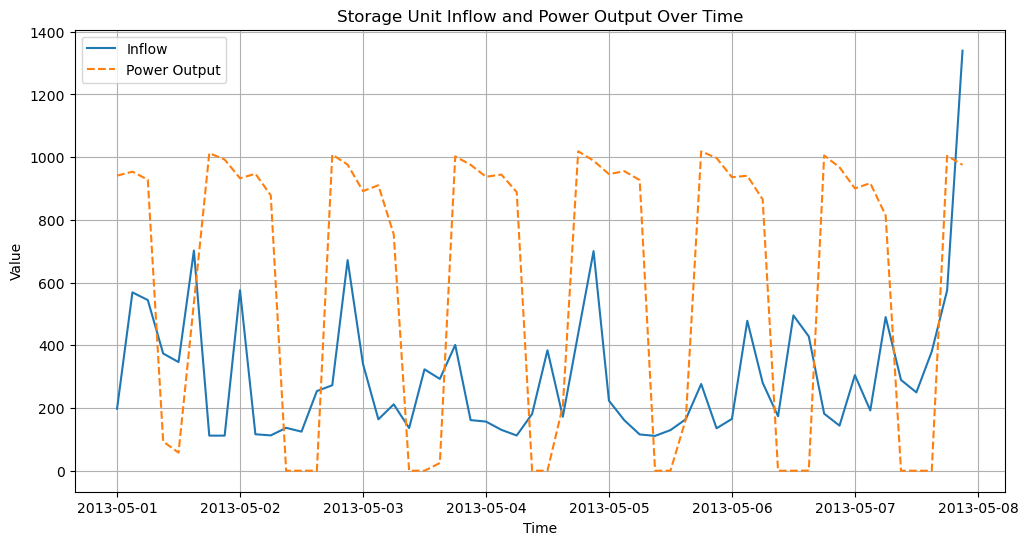

In [56]:
n.storage_units_t.inflow
type(n.storage_units_t.p)

# Assuming n.storage_units_t.inflow and n.storage_units_t.p are Pandas DataFrames
fig, ax = plt.subplots(figsize=(12, 6))

# Plot inflow
ax.plot(n.storage_units_t.inflow.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'], label='Inflow', linestyle='-', marker='')

# Plot p
ax.plot(n.storage_units_t.p.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'], label='Power Output', linestyle='--', marker='')

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('Storage Unit Inflow and Power Output Over Time')
ax.legend()
ax.grid(True)

plt.show()

<AxesSubplot:xlabel='snapshot'>

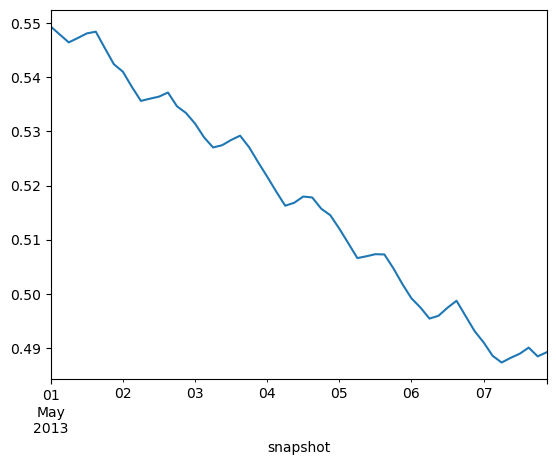

In [57]:
(n.storage_units_t.state_of_charge.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'] / 1e6).plot()

In [58]:
n.storage_units.p_nom * n.storage_units.max_hours

StorageUnit
GH.11_2_AC hydro    8.511236e+05
GH.6_2_AC hydro     2.148876e+06
dtype: float64

In [79]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas       3952.154566         3952.154566   
            Offshore Wind (DC)          0.000049            0.000000   
            Oil                       509.484522          509.484522   
            Onshore Wind              314.181800            0.000000   
            Run of River              160.000000          160.000000   
            Solar                    9615.070230          168.954000   
Line        AC                      20392.073854        20278.920137   
Link        H2 electrolysis           782.267599            0.000000   
            H2 fuel cell              465.681202            0.000000   
            battery charger          1454.010084            0.000000   
            battery discharger       1615.566760            0.000000   
Load        -                           0.000000            0.000000   
StorageUnit Reservoir & Dam          1424.000000         1424.000000   
Store       Battery Storage          8603.302257            0.000000   
            Hydrogen Storage         7525.170733            0.000000   

                                      Supply    Withdrawal      Dispatch  \
Generator   Combined-Cycle Gas  0.000000e+00  0.000000e+00  0.000000e+00   
            Offshore Wind (DC)  2.986375e-02  0.000000e+00  2.986375e-02   
            Oil                 0.000000e+00  0.000000e+00  0.000000e+00   
            Onshore Wind        2.913540e+05  0.000000e+00  2.913540e+05   
            Run of River        1.401528e+06  0.000000e+00  1.401528e+06   
            Solar               1.131490e+07  0.000000e+00  1.131490e+07   
Line        AC                  2.769693e+07  2.769693e+07  0.000000e+00   
Link        H2 electrolysis     6.938188e+05  8.672736e+05 -1.734547e+05   
            H2 fuel cell        4.024149e+05  6.938188e+05 -2.914039e+05   
            battery charger     2.722818e+06  3.025354e+06 -3.025354e+05   
            battery discharger  2.450536e+06  2.722818e+06 -2.722818e+05   
Load        -                   0.000000e+00  1.965415e+07 -1.965415e+07   
StorageUnit Reservoir & Dam     7.686043e+06  0.000000e+00  7.686043e+06   
Store       Battery Storage     2.722279e+06  2.722279e+06 -1.818350e-10   
            Hydrogen Storage    6.934614e+05  6.934614e+05 -1.624372e-10   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas      0.000000         0.000000  0.000000e+00   
            Offshore Wind (DC)      0.000000         0.070139  1.812026e-02   
            Oil                     0.000000         0.000000  0.000000e+00   
            Onshore Wind            0.000000         0.105861  5.173460e+04   
            Run of River            0.000000         0.999948  0.000000e+00   
            Solar                   0.000000         0.134337  1.514736e+06   
Line        AC                 -26507.690442         0.155048  0.000000e+00   
Link        H2 electrolysis         0.000000         0.126560  0.000000e+00   
            H2 fuel cell            0.000000         0.170080  0.000000e+00   
            battery charger         0.000000         0.237522  0.000000e+00   
            battery discharger      0.000000         0.192393  0.000000e+00   
Load        -                       0.000000              NaN  0.000000e+00   
StorageUnit Reservoir & Dam         0.000000         0.616153  0.000000e+00   
Store       Battery Storage         0.000000         0.437892  0.000000e+00   
            Hydrogen Storage        0.000000         0.504564  0.000000e+00   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         3.338350e+08             0.000000e+00   
            Offshore Wind (DC)         1.223816e+01             7.200124e-04   
            Oil                        1.947992e+07             0.000000e+00   
            Onshore Wind               3.433868e+07             7.536445e+03 

In [75]:
energy_balance_check = n.statistics.energy_balance().loc[:, :, "AC"]
energy_balance_check

component    carrier           
StorageUnit  Reservoir & Dam       7.686043e+06
Link         H2 electrolysis      -8.672736e+05
             battery charger      -3.025354e+06
             H2 fuel cell          4.024149e+05
             battery discharger    2.450536e+06
Load         -                    -1.965415e+07
Generator    Offshore Wind (DC)    2.986375e-02
             Onshore Wind          2.913540e+05
             Run of River          1.401528e+06
             Solar                 1.131490e+07
dtype: float64

In [72]:
n.statistics.energy_balance()

component    carrier             bus_carrier
StorageUnit  Reservoir & Dam     AC             7.686043e+06
Link         H2 electrolysis     AC            -8.672736e+05
             H2 fuel cell        H2            -6.938188e+05
             battery charger     AC            -3.025354e+06
             battery discharger  battery       -2.722818e+06
             H2 electrolysis     H2             6.938188e+05
             H2 fuel cell        AC             4.024149e+05
             battery charger     battery        2.722818e+06
             battery discharger  AC             2.450536e+06
Store        Battery Storage     battery       -1.818350e-10
             Hydrogen Storage    H2            -1.624372e-10
Load         -                   AC            -1.965415e+07
Generator    Offshore Wind (DC)  AC             2.986375e-02
             Onshore Wind        AC             2.913540e+05
             Run of River        AC             1.401528e+06
             Solar               AC     

In [73]:
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
print(energy_balance)

carrier          -  H2 electrolysis  H2 fuel cell  Offshore Wind (DC)  \
0       -19.654152        -0.867274      0.402415        2.986375e-08   

carrier  Onshore Wind  Reservoir & Dam  Run of River      Solar  \
0            0.291354         7.686043      1.401528  11.314903   

carrier  battery charger  battery discharger  
0              -3.025354            2.450536  


<AxesSubplot:xlabel='component,carrier'>

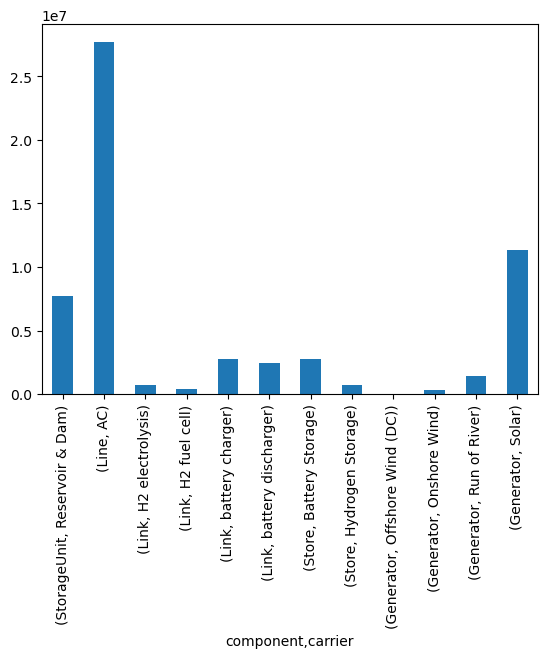

In [66]:
n.statistics.supply().plot.bar()

/tmp/ipykernel_18353/968957247.py:1: DeprecatedWarning: dispatch is deprecated as of 0.28 and will be removed in 0.29. Use 'energy_balance' instead.
  (n.statistics.dispatch() / 1e6).plot.bar()


<AxesSubplot:xlabel='component,carrier'>

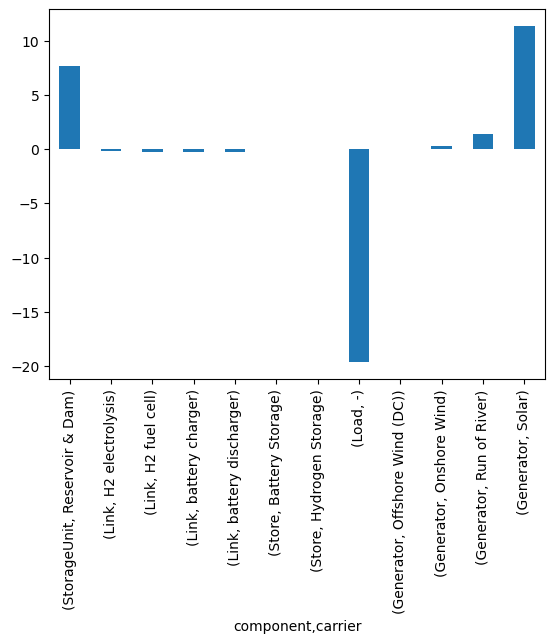

In [68]:
(n.statistics.dispatch() / 1e6).plot.bar()